# CheXpert — Patient-grouped split & Dataset

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_ROOT = Path(r"D:\CheXpert-v1.0-small")     # source CSVs
OUT_DIR   = Path(r"d:\My Projects\chest-xray-bench\data")   # where split CSVs go
OUT_DIR.mkdir(exist_ok=True)

TARGET_TASKS = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]

# Load train, keep frontal only, parse patient id from the path
train_df = pd.read_csv(DATA_ROOT / "train.csv")
train_df = train_df[train_df["Frontal/Lateral"] == "Frontal"].copy()
train_df["patient_id"] = train_df["Path"].str.extract(r"(patient\d+)", expand=False)

print("frontal train rows:", len(train_df))
print("unique patients   :", train_df["patient_id"].nunique())
print("OUT_DIR           :", OUT_DIR)


frontal train rows: 191027
unique patients   : 64534
OUT_DIR           : d:\My Projects\chest-xray-bench\data


In [2]:
# Patient-grouped split: carve an in-loop validation set out of train (frozen, reproducible)
from sklearn.model_selection import GroupShuffleSplit

VAL_FRAC = 0.1      # fraction of PATIENTS held out for in-loop validation
SEED     = 42        # fixed -> split is reproducible/frozen across all experiments

def uones_rate(df):  # U-Ones positive rate per target task (pos + uncertain), % of rows
    return {t: round(100 * df[t].isin([1, -1]).mean(), 2) for t in TARGET_TASKS}

print("=" * 60)
print("BEFORE split")
print(f"  total frontal rows : {len(train_df)}")
print(f"  unique patients    : {train_df['patient_id'].nunique()}")
print(f"  U-Ones %pos        : {uones_rate(train_df)}")
print("=" * 60)

gss = GroupShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
tr_idx, va_idx = next(gss.split(train_df, groups=train_df["patient_id"]))
tr = train_df.iloc[tr_idx].copy()
va = train_df.iloc[va_idx].copy()

p_tr, p_va = set(tr["patient_id"]), set(va["patient_id"])
print("AFTER split")
print(f"  VAL_FRAC={VAL_FRAC}  SEED={SEED}")
print(f"  train rows : {len(tr):>7d}  ({100*len(tr)/len(train_df):.1f}%)   patients: {len(p_tr)}")
print(f"  val   rows : {len(va):>7d}  ({100*len(va)/len(train_df):.1f}%)   patients: {len(p_va)}")
print(f"  shared patients (must be 0): {len(p_tr & p_va)}")
print(f"  train U-Ones %pos : {uones_rate(tr)}")
print(f"  val   U-Ones %pos : {uones_rate(va)}")
print("=" * 60)


BEFORE split
  total frontal rows : 191027
  unique patients    : 64534
  U-Ones %pos        : {'Atelectasis': np.float64(31.19), 'Cardiomegaly': np.float64(15.75), 'Consolidation': np.float64(19.56), 'Edema': np.float64(32.19), 'Pleural Effusion': np.float64(45.27)}
AFTER split
  VAL_FRAC=0.1  SEED=42
  train rows :  171927  (90.0%)   patients: 58080
  val   rows :   19100  (10.0%)   patients: 6454
  shared patients (must be 0): 0
  train U-Ones %pos : {'Atelectasis': np.float64(31.2), 'Cardiomegaly': np.float64(15.73), 'Consolidation': np.float64(19.52), 'Edema': np.float64(32.25), 'Pleural Effusion': np.float64(45.32)}
  val   U-Ones %pos : {'Atelectasis': np.float64(31.12), 'Cardiomegaly': np.float64(15.92), 'Consolidation': np.float64(19.9), 'Edema': np.float64(31.69), 'Pleural Effusion': np.float64(44.84)}


In [3]:
# Write the frozen split CSVs to data/  (01_train.csv, 01_val.csv)
train_out = OUT_DIR / "01_train.csv"
val_out   = OUT_DIR / "01_val.csv"

print("WRITING")
print(f"  {train_out}  <-  {len(tr)} rows, {len(tr.columns)} cols")
print(f"  {val_out}  <-  {len(va)} rows, {len(va.columns)} cols")
print(f"  columns: {list(tr.columns)}")

tr.to_csv(train_out, index=False)
va.to_csv(val_out, index=False)

# Read back and verify integrity
tr_chk = pd.read_csv(train_out)
va_chk = pd.read_csv(val_out)
p_tr_chk = set(tr_chk["patient_id"]); p_va_chk = set(va_chk["patient_id"])

print("\nVERIFY (read back from disk)")
print(f"  01_train.csv : {len(tr_chk)} rows  (matches: {len(tr_chk)==len(tr)})   patients: {len(p_tr_chk)}")
print(f"  01_val.csv   : {len(va_chk)} rows  (matches: {len(va_chk)==len(va)})   patients: {len(p_va_chk)}")
print(f"  shared patients across saved files (must be 0): {len(p_tr_chk & p_va_chk)}")
print(f"  total saved rows: {len(tr_chk)+len(va_chk)}  (== frontal train {len(train_df)}: {len(tr_chk)+len(va_chk)==len(train_df)})")


WRITING
  d:\My Projects\chest-xray-bench\data\01_train.csv  <-  171927 rows, 20 cols
  d:\My Projects\chest-xray-bench\data\01_val.csv  <-  19100 rows, 20 cols
  columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'patient_id']

VERIFY (read back from disk)
  01_train.csv : 171927 rows  (matches: True)   patients: 58080
  01_val.csv   : 19100 rows  (matches: True)   patients: 6454
  shared patients across saved files (must be 0): 0
  total saved rows: 191027  (== frontal train 191027: True)


train rows: 171927   val rows: 19100


,train pos,train %pos,train neg,val pos,val %pos,val neg
task,,,,,,
Atelectasis,53640,31.20,118287,5943,31.12,13157
Cardiomegaly,27052,15.73,144875,3040,15.92,16060
Consolidation,33564,19.52,138363,3800,19.90,15300
Edema,55441,32.25,116486,6052,31.69,13048
Pleural Effusion,77912,45.32,94015,8565,44.84,10535


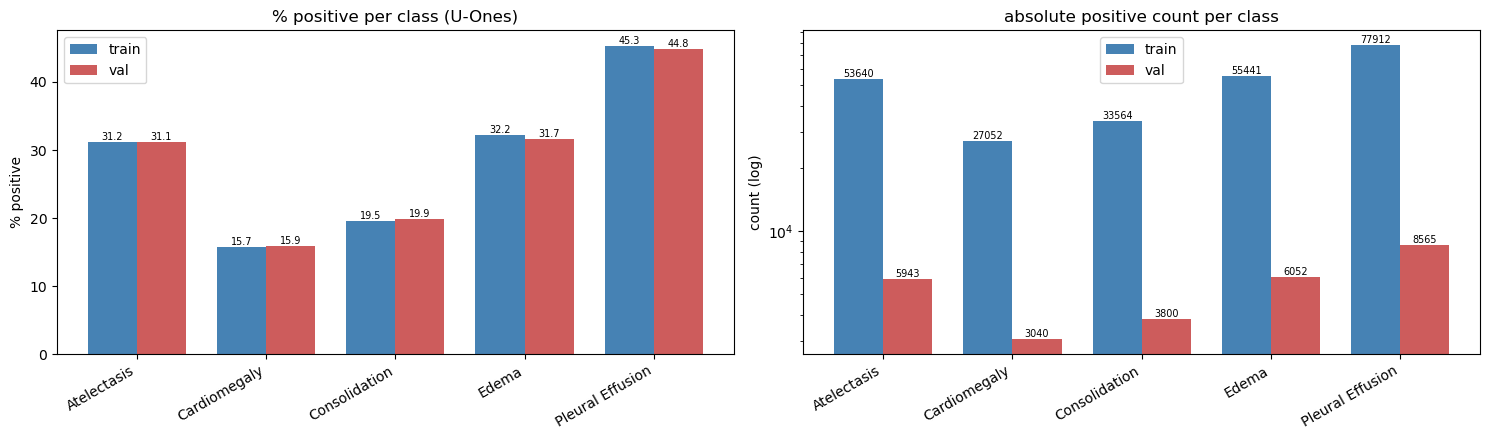

In [4]:
# Per-class distribution comparison: train vs val (U-Ones positives)
import matplotlib.pyplot as plt

rows = []
for t in TARGET_TASKS:
    tr_pos = int(tr[t].isin([1, -1]).sum()); tr_n = len(tr)
    va_pos = int(va[t].isin([1, -1]).sum()); va_n = len(va)
    rows.append({
        "task": t,
        "train pos": tr_pos, "train %pos": round(100*tr_pos/tr_n, 2),
        "train neg": tr_n - tr_pos,
        "val pos":   va_pos, "val %pos":   round(100*va_pos/va_n, 2),
        "val neg":   va_n - va_pos,
    })
dist = pd.DataFrame(rows).set_index("task")
print(f"train rows: {len(tr)}   val rows: {len(va)}")
display(dist)

x = np.arange(len(TARGET_TASKS)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
# (1) % positive per class
axes[0].bar(x - w/2, dist["train %pos"], w, label="train", color="steelblue")
axes[0].bar(x + w/2, dist["val %pos"],   w, label="val",   color="indianred")
axes[0].set_title("% positive per class (U-Ones)"); axes[0].set_ylabel("% positive")
for i in x:
    axes[0].text(i-w/2, dist["train %pos"].iloc[i], f'{dist["train %pos"].iloc[i]:.1f}', ha="center", va="bottom", fontsize=7)
    axes[0].text(i+w/2, dist["val %pos"].iloc[i],   f'{dist["val %pos"].iloc[i]:.1f}',   ha="center", va="bottom", fontsize=7)
# (2) absolute positive counts (log scale -> see val has enough)
axes[1].bar(x - w/2, dist["train pos"], w, label="train", color="steelblue")
axes[1].bar(x + w/2, dist["val pos"],   w, label="val",   color="indianred")
axes[1].set_title("absolute positive count per class"); axes[1].set_ylabel("count (log)"); axes[1].set_yscale("log")
for i in x:
    axes[1].text(i-w/2, dist["train pos"].iloc[i], f'{dist["train pos"].iloc[i]}', ha="center", va="bottom", fontsize=7)
    axes[1].text(i+w/2, dist["val pos"].iloc[i],   f'{dist["val pos"].iloc[i]}',   ha="center", va="bottom", fontsize=7)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(TARGET_TASKS, rotation=30, ha="right"); ax.legend()
plt.tight_layout(); plt.show()

## Dataset — label policy, preprocessing, and the `Dataset` class

In [6]:
# Label builder: turn raw labels (1/0/-1/blank) into a target vector per uncertainty policy
# policy: "ones" (-1 -> 1)  |  "zeros" (-1 -> 0).   blanks/NaN -> 0 always.
def build_labels(df, tasks=TARGET_TASKS, policy="ones"):
    target = df[tasks].fillna(0).copy()        # blanks -> 0
    if policy == "ones":
        target = target.replace(-1, 1)
    elif policy == "zeros":
        target = target.replace(-1, 0)
    else:
        raise ValueError(f"unknown policy: {policy}")
    return target.astype("float32")

# Quick verification on the first few train rows, both policies
sample = tr.head(6)
print("raw labels (first 6 train rows):")
print(sample[TARGET_TASKS].to_string())
for pol in ["ones", "zeros"]:
    print(f"\npolicy = {pol}")
    print(build_labels(sample, policy=pol).to_string())


raw labels (first 6 train rows):
   Atelectasis  Cardiomegaly  Consolidation  Edema  Pleural Effusion
0          NaN           NaN            NaN    NaN               NaN
1         -1.0          -1.0           -1.0   -1.0              -1.0
2          NaN           NaN           -1.0    NaN               NaN
4          NaN           NaN            NaN    1.0               NaN
5          NaN           NaN            0.0    NaN               0.0
7          NaN           0.0            0.0    NaN               0.0

policy = ones
   Atelectasis  Cardiomegaly  Consolidation  Edema  Pleural Effusion
0          0.0           0.0            0.0    0.0               0.0
1          1.0           1.0            1.0    1.0               1.0
2          0.0           0.0            1.0    0.0               0.0
4          0.0           0.0            0.0    1.0               0.0
5          0.0           0.0            0.0    0.0               0.0
7          0.0           0.0            0.0    0.0     

image: CheXpert-v1.0-small/train/patient21708/study1/view1_frontal.jpg
use_clahe=False  shape=(3, 320, 384)  dtype=torch.float32  min=-2.118  max=2.640  per-ch mean=[0.061, 0.191, 0.413]
use_clahe=True  shape=(3, 320, 384)  dtype=torch.float32  min=-2.118  max=2.640  per-ch mean=[0.091, 0.223, 0.444]
(expected shape (3, 320, 384) = C, H, W; black bars = zero-pad)


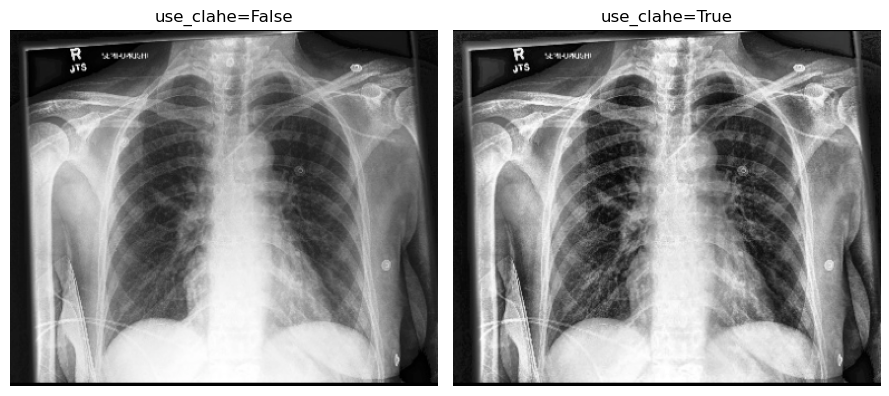

In [52]:
# Image preprocessing: grayscale -> [CLAHE] -> aspect-preserving resize + center zero-pad -> 3ch -> ImageNet-norm -> tensor
import cv2
import torch
from PIL import Image

IMG_W, IMG_H   = 384, 320       # width x height (divisible by 16/32; matches native ~390x320 majority)
IMAGENET_MEAN  = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD   = np.array([0.229, 0.224, 0.225], dtype=np.float32)
CLAHE_CLIP, CLAHE_TILE = 2.0, (8, 8)
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def resolve_path(rel):
    for base in (DATA_ROOT.parent, DATA_ROOT):
        p = base / rel
        if p.exists():
            return p
    return None

def resize_pad(img, out_w=IMG_W, out_h=IMG_H):
    """Resize preserving aspect ratio to fit inside (out_w,out_h), then center zero-pad to exactly that size."""
    h0, w0 = img.shape
    scale = min(out_w / w0, out_h / h0)
    new_w, new_h = max(1, round(w0 * scale)), max(1, round(h0 * scale))
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)   # INTER_AREA for all (good downscale)
    canvas = np.zeros((out_h, out_w), dtype=img.dtype)                    # 0 = black background
    top, left = (out_h - new_h) // 2, (out_w - new_w) // 2               # center placement
    canvas[top:top + new_h, left:left + new_w] = img
    return canvas

def preprocess(rel_path, use_clahe=False):
    img = np.asarray(Image.open(resolve_path(rel_path)).convert("L"))    # grayscale uint8
    if use_clahe:
        img = _clahe.apply(img)
    img = resize_pad(img)                                                # -> (IMG_H, IMG_W) uint8
    img = np.stack([img, img, img], axis=-1).astype(np.float32) / 255.0  # 3ch, [0,1]
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1))                      # (C,H,W) float32

# Verify on a RANDOM image, no-CLAHE vs CLAHE
rel = tr.sample(1)["Path"].iloc[0]
print(f"image: {rel}")
for flag in [False, True]:
    t = preprocess(rel, use_clahe=flag)
    print(f"use_clahe={flag}  shape={tuple(t.shape)}  dtype={t.dtype}  "
          f"min={t.min():.3f}  max={t.max():.3f}  per-ch mean={[round(float(t[c].mean()),3) for c in range(3)]}")
print("(expected shape (3, 320, 384) = C, H, W; black bars = zero-pad)")

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, flag in zip(ax, [False, True]):
    disp = preprocess(rel, use_clahe=flag).numpy().transpose(1,2,0)
    disp = (disp * IMAGENET_STD + IMAGENET_MEAN).clip(0,1)   # un-normalize for display
    a.imshow(disp); a.set_title(f"use_clahe={flag}"); a.axis("off")
plt.tight_layout(); plt.show()

In [53]:
# Dataset class: ties preprocess() + build_labels() together -> (image_tensor, label_tensor)
from torch.utils.data import Dataset

class CheXpertDataset(Dataset):
    def __init__(self, df, tasks=TARGET_TASKS, policy="ones", use_clahe=False):
        self.paths   = df["Path"].tolist()
        self.labels  = torch.from_numpy(build_labels(df, tasks, policy).to_numpy())  # (N, n_tasks) f32
        self.tasks   = tasks
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = preprocess(self.paths[i], use_clahe=self.use_clahe)   # (3,H,W) float32
        return img, self.labels[i]                                  # (n_tasks,) float32

# Verification on a random item
ds = CheXpertDataset(tr, policy="ones", use_clahe=False)
i = np.random.randint(len(ds))
img, label = ds[i]
print(f"dataset length     : {len(ds)}")
print(f"sampled index      : {i}")
print(f"path               : {ds.paths[i]}")
print(f"image  -> shape {tuple(img.shape)}  dtype {img.dtype}  min {img.min():.3f}  max {img.max():.3f}")
print(f"label  -> shape {tuple(label.shape)}  dtype {label.dtype}  values {label.tolist()}")
print(f"tasks              : {ds.tasks}")
print("\ncross-check vs raw row (U-Ones: -1 and 1 -> 1, blank/0 -> 0):")
print(tr.iloc[i][TARGET_TASKS].to_string())

dataset length     : 171927
sampled index      : 66232
path               : CheXpert-v1.0-small/train/patient22282/study1/view1_frontal.jpg
image  -> shape (3, 320, 384)  dtype torch.float32  min -2.118  max 2.640
label  -> shape (5,)  dtype torch.float32  values [0.0, 0.0, 0.0, 0.0, 0.0]
tasks              : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

cross-check vs raw row (U-Ones: -1 and 1 -> 1, blank/0 -> 0):
Atelectasis         NaN
Cardiomegaly        NaN
Consolidation       0.0
Edema               NaN
Pleural Effusion    0.0


In [54]:
# DataLoader batch sanity check (num_workers=0 for Windows/Jupyter; raise on Modal/Linux)
import time
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_ds = CheXpertDataset(tr, policy="ones", use_clahe=False)
val_ds   = CheXpertDataset(va, policy="ones", use_clahe=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train: {len(train_ds)} imgs -> {len(train_loader)} batches")
print(f"val  : {len(val_ds)} imgs -> {len(val_loader)} batches")
print(f"batch size: {BATCH_SIZE}")

# Pull one batch and inspect
imgs, labels = next(iter(train_loader))
print(f"\none batch:")
print(f"  imgs   -> shape {tuple(imgs.shape)}  dtype {imgs.dtype}  min {imgs.min():.3f}  max {imgs.max():.3f}")
print(f"  labels -> shape {tuple(labels.shape)}  dtype {labels.dtype}")
print(f"  per-task positives in this batch: {labels.sum(0).tolist()}")

# Rough throughput over a few batches
N = 5
t0 = time.time()
for k, _ in zip(range(N), train_loader):
    pass
dt = time.time() - t0
print(f"\nthroughput: {dt/N:.3f}s/batch over {N} batches  (~{BATCH_SIZE*N/dt:.0f} imgs/s, single-process)")

train: 171927 imgs -> 5373 batches
val  : 19100 imgs -> 597 batches
batch size: 32

one batch:
  imgs   -> shape (32, 3, 320, 384)  dtype torch.float32  min -2.118  max 2.640
  labels -> shape (32, 5)  dtype torch.float32
  per-task positives in this batch: [13.0, 2.0, 4.0, 10.0, 19.0]

throughput: 0.192s/batch over 5 batches  (~167 imgs/s, single-process)


scanned 4000 train frontals; picked (closest to target widths):
  target 320 -> 320x320   CheXpert-v1.0-small/train/patient18136/study1/view1_frontal.jpg
  target 390 -> 390x320   CheXpert-v1.0-small/train/patient01137/study2/view1_frontal.jpg
  target 930 -> 488x320   CheXpert-v1.0-small/train/patient07379/study22/view1_frontal.jpg


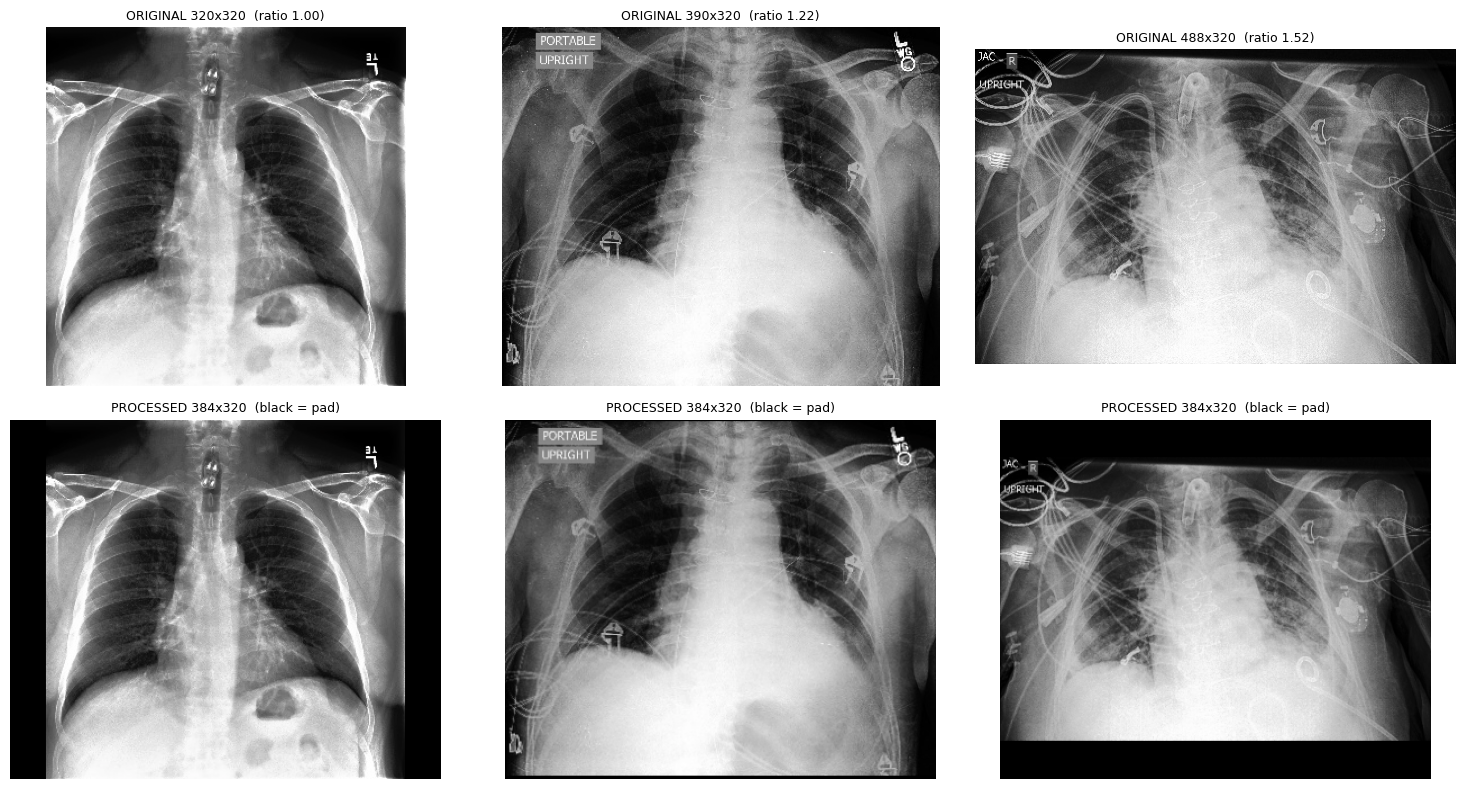

In [55]:
# Visualize resize+pad on different native resolutions (square / typical ~390x320 / wide)
# Scan a random sample of train frontals, then pick examples closest to target widths.
SCAN_N = 4000
TARGET_WIDTHS = [320, 390, 930]   # square / typical / wide

scan_paths = tr["Path"].sample(min(SCAN_N, len(tr))).tolist()
sizes = []
for rel in scan_paths:
    with Image.open(resolve_path(rel)) as im:
        sizes.append((rel, im.size[0], im.size[1]))   # (path, w, h)
ws = np.array([s[1] for s in sizes])

picks = [sizes[int(np.argmin(np.abs(ws - tw)))] for tw in TARGET_WIDTHS]
print(f"scanned {len(sizes)} train frontals; picked (closest to target widths):")
for tw, (rel, w, h) in zip(TARGET_WIDTHS, picks):
    print(f"  target {tw:>3} -> {w}x{h}   {rel}")

fig, axes = plt.subplots(2, len(picks), figsize=(5 * len(picks), 8))
for col, (rel, w, h) in enumerate(picks):
    orig = np.asarray(Image.open(resolve_path(rel)).convert("L"))
    proc = preprocess(rel).numpy().transpose(1, 2, 0)
    proc = (proc * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)   # un-normalize for display
    axes[0, col].imshow(orig, cmap="gray"); axes[0, col].set_title(f"ORIGINAL {w}x{h}  (ratio {w/h:.2f})", fontsize=9)
    axes[1, col].imshow(proc);              axes[1, col].set_title("PROCESSED 384x320  (black = pad)", fontsize=9)
    axes[0, col].axis("off"); axes[1, col].axis("off")
plt.tight_layout(); plt.show()